In [2]:
import CalculatedFieldSubroutines as cfs

#

import numpy as np

import pandas as pd

#

import matplotlib.pyplot as plt

from pandasgui import show

#

import warnings

In [3]:
warnings.filterwarnings( 'ignore' )

In [4]:
gmID_list = cfs.list_whitelisted_gmIDs()

In [5]:
window_size = 10 # sec

window_size_ns = window_size * 1e9

#

stddev_val_diff_dict = {}

#

for gmID in gmID_list:

    df = cfs.retrieve_gmID_preprocessed_moving_data_v3( gmID = gmID, moving_window = 0 )

    #

    cfs.solColumns( df )

    #

    solType_transition_array = np.array( df[ 'solChange' ] )

    solType_transition_type_array = np.array( df[ 'Changesol' ] )

    #

    time_array = np.array( df[ 'time' ] )

    #

    steeringPercentage_array = np.array( df[ 'steeringPercentage' ] )

    #

    if 1 in solType_transition_array:

        #

        transition_indexes = np.where( solType_transition_array == 1 )[ 0 ]

        #

        for transition_index in transition_indexes:

            #

            single_moving_window_indexes_before = cfs.single_moving_window_indexer( moving_col_array = time_array,
                                                                                    index = transition_index,
                                                                                    relative_moving_window_interval = ( -1 * window_size_ns, 0 ) )

            single_moving_window_indexes_after = cfs.single_moving_window_indexer( moving_col_array = time_array,
                                                                                   index = transition_index,
                                                                                   relative_moving_window_interval = ( 0, window_size_ns ) )

            #

            stddev_val_before = np.std( steeringPercentage_array[ single_moving_window_indexes_before ] )

            stddev_val_after = np.std( steeringPercentage_array[ single_moving_window_indexes_after ] )

            #

            stddev_val_diff = stddev_val_after - stddev_val_before

            #

            solType_transition_type = solType_transition_type_array[ transition_index ]

            #

            if solType_transition_type not in stddev_val_diff_dict.keys():

                #

                stddev_val_diff_dict[ solType_transition_type ] = np.array( [] )

            #

            stddev_val_diff_dict[ solType_transition_type ] = np.append( stddev_val_diff_dict[ solType_transition_type ], stddev_val_diff )

In [10]:
for key, val in stddev_val_diff_dict.items():

    stddev_val_diff_dict[ key ] =  val[ ~np.isnan( val ) ]

In [11]:
count_dict = {}

for key, val in stddev_val_diff_dict.items():

    count_dict[ key ] =  len( val )

In [20]:
count_df = pd.DataFrame()

count_df[ 'SolTypeTransition' ] = list( count_dict.keys() )

count_df[ 'counts' ] = list( count_dict.values() )

count_df = count_df.sort_values( 'counts' )

count_df = count_df.reset_index( drop = True )

count_df

,SolTypeTransition,counts
0,PSRDIFF->L1_FLOAT,1
1,L1_FLOAT->PSRDIFF,1
2,NARROW_FLOAT->L1_FLOAT,1
3,NARROW_INT->L1_FLOAT,3
4,NARROW_INT->SINGLE,4
5,L1_FLOAT->NARROW_FLOAT,4
6,NARROW_FLOAT->SINGLE,8
7,WIDE_INT->NARROW_FLOAT,8
8,NARROW_INT->WIDE_INT,8
9,WIDE_INT->PSRDIFF,9


In [21]:
count_df[ 'SolTypeTransition' ][ 0 ]

'PSRDIFF->L1_FLOAT'

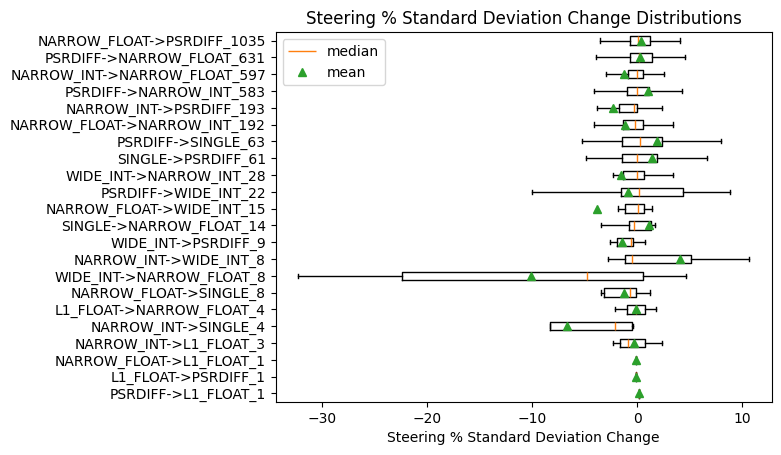

In [37]:
plt.title( f'Steering % Standard Deviation Change Distributions' )

arrays_to_plot = [ stddev_val_diff_dict[ solType_transition ] for solType_transition, counts in
                   zip( count_df[ 'SolTypeTransition' ], count_df[ 'counts' ] ) ]

labels = [ f'{ solType_transition }_{ counts }' for solType_transition, counts in 
           zip( count_df[ 'SolTypeTransition' ], count_df[ 'counts' ] ) ]

bp = plt.boxplot( arrays_to_plot, vert = False, showfliers = False, showmeans = True )

plt.yticks( [ i for i in range( 1, len( stddev_val_diff_dict ) + 1 ) ], labels )

plt.xlabel( 'Steering % Standard Deviation Change' )

plt.legend( [ bp[ 'medians' ][ 0 ] , bp[ 'means' ][ 0 ] ], [ 'median', 'mean' ] )

plt.show()

In [4]:
window_size = 10 # sec

window_size_ns = window_size * 1e9

#

val_diff_dict = {}

#

for gmID in gmID_list:

    df = cfs.retrieve_gmID_preprocessed_moving_data_v3( gmID = gmID, moving_window = 0 )

    #

    cfs.solColumns( df )

    #

    solType_transition_array = np.array( df[ 'solChange' ] )

    solType_transition_type_array = np.array( df[ 'Changesol' ] )

    #

    time_array = np.array( df[ 'time' ] )

    #

    LatLonTotalStdDev_array = np.array( df[ 'LatLonTotalStdDev' ] )

    #

    if 1 in solType_transition_array:

        #

        transition_indexes = np.where( solType_transition_array == 1 )[ 0 ]

        #

        for transition_index in transition_indexes:

            #

            single_moving_window_indexes_before = cfs.single_moving_window_indexer( moving_col_array = time_array,
                                                                                    index = transition_index,
                                                                                    relative_moving_window_interval = ( -1 * window_size_ns, 0 ) )

            single_moving_window_indexes_after = cfs.single_moving_window_indexer( moving_col_array = time_array,
                                                                                   index = transition_index,
                                                                                   relative_moving_window_interval = ( 0, window_size_ns ) )

            #

            val_before = np.mean( LatLonTotalStdDev_array[ single_moving_window_indexes_before ] )

            val_after = np.mean( LatLonTotalStdDev_array[ single_moving_window_indexes_after ] )

            #

            val_diff = val_after - val_before

            #

            solType_transition_type = solType_transition_type_array[ transition_index ]

            #

            if solType_transition_type not in val_diff_dict.keys():

                #

                val_diff_dict[ solType_transition_type ] = np.array( [] )

            #

            val_diff_dict[ solType_transition_type ] = np.append( val_diff_dict[ solType_transition_type ], val_diff )

In [10]:
for key, val in val_diff_dict.items():

    val_diff_dict[ key ] = val[ ~np.isnan( val ) ]

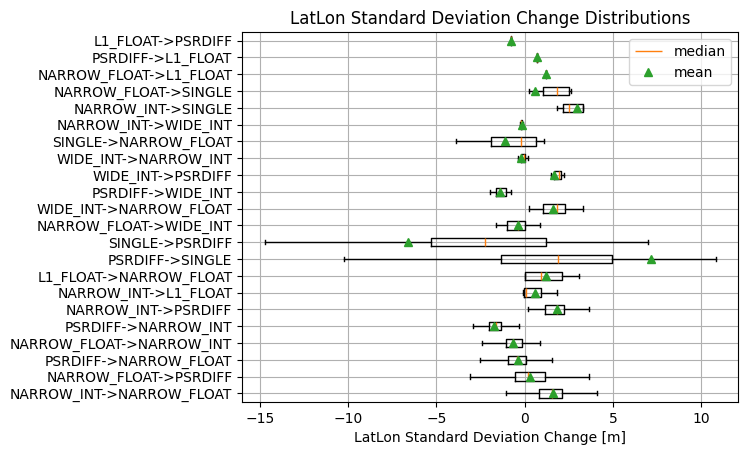

In [11]:
plt.title( f'LatLon Standard Deviation Change Distributions' )

bp = plt.boxplot( list( val_diff_dict.values() ), vert = False, showfliers = False, showmeans = True )

plt.yticks( [ i for i in range( 1, len( val_diff_dict ) + 1 ) ], list( val_diff_dict.keys() ) )

plt.xlabel( 'LatLon Standard Deviation Change [m]' )

plt.legend( [ bp[ 'medians' ][ 0 ] , bp[ 'means' ][ 0 ] ], [ 'median', 'mean' ] )

plt.grid()

plt.show()

In [8]:
for key, val in val_diff_dict.items():

    print( len( val ), key )

597 NARROW_INT->NARROW_FLOAT
1036 NARROW_FLOAT->PSRDIFF
631 PSRDIFF->NARROW_FLOAT
192 NARROW_FLOAT->NARROW_INT
583 PSRDIFF->NARROW_INT
194 NARROW_INT->PSRDIFF
3 NARROW_INT->L1_FLOAT
4 L1_FLOAT->NARROW_FLOAT
63 PSRDIFF->SINGLE
61 SINGLE->PSRDIFF
15 NARROW_FLOAT->WIDE_INT
8 WIDE_INT->NARROW_FLOAT
22 PSRDIFF->WIDE_INT
9 WIDE_INT->PSRDIFF
28 WIDE_INT->NARROW_INT
14 SINGLE->NARROW_FLOAT
8 NARROW_INT->WIDE_INT
4 NARROW_INT->SINGLE
8 NARROW_FLOAT->SINGLE
1 NARROW_FLOAT->L1_FLOAT
1 PSRDIFF->L1_FLOAT
1 L1_FLOAT->PSRDIFF


In [12]:
val_diff_dict.keys()

dict_keys(['NARROW_INT->NARROW_FLOAT', 'NARROW_FLOAT->PSRDIFF', 'PSRDIFF->NARROW_FLOAT', 'NARROW_FLOAT->NARROW_INT', 'PSRDIFF->NARROW_INT', 'NARROW_INT->PSRDIFF', 'NARROW_INT->L1_FLOAT', 'L1_FLOAT->NARROW_FLOAT', 'PSRDIFF->SINGLE', 'SINGLE->PSRDIFF', 'NARROW_FLOAT->WIDE_INT', 'WIDE_INT->NARROW_FLOAT', 'PSRDIFF->WIDE_INT', 'WIDE_INT->PSRDIFF', 'WIDE_INT->NARROW_INT', 'SINGLE->NARROW_FLOAT', 'NARROW_INT->WIDE_INT', 'NARROW_INT->SINGLE', 'NARROW_FLOAT->SINGLE', 'NARROW_FLOAT->L1_FLOAT', 'PSRDIFF->L1_FLOAT', 'L1_FLOAT->PSRDIFF'])